In [68]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [69]:
df=pd.read_csv("/content/housing.csv")

EDA

In [70]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [71]:
df.shape

(20640, 10)

<Axes: xlabel='housing_median_age', ylabel='Count'>

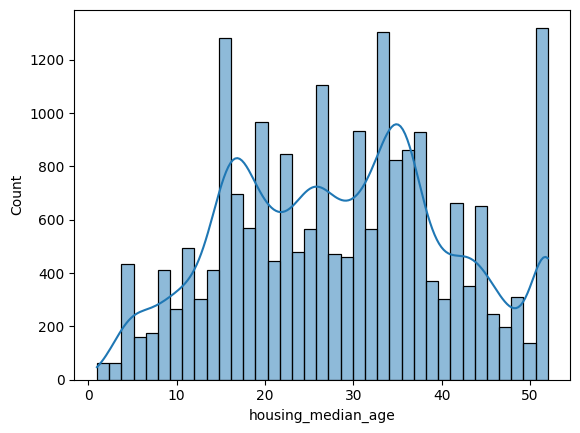

In [72]:
sns.histplot(df,x="housing_median_age",kde=True)

The distribution of housing_median_age reveals a multimodal pattern with noticeable construction waves peaking around 16, 26, and 35 years, alongside a severe artificial spike at the upper boundary near 52 years caused by value capping during data collection. This right-hand concentration represents a truncated data artifact rather than a true natural frequency, which can distort model training and standard distribution metrics if left untreated. To ensure feature integrity, instances where housing_median_age reaches this maximum ceiling should either be filtered out, explicitly flagged, or transformed prior to downstream feature engineering and modeling.

<Axes: xlabel='ocean_proximity', ylabel='housing_median_age'>

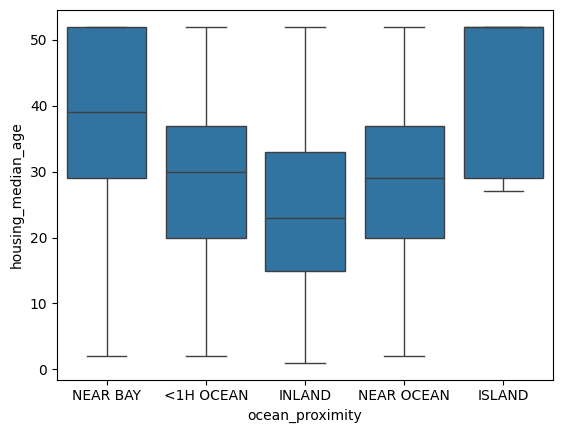

In [73]:
sns.boxplot(df,x="ocean_proximity",y="housing_median_age")

A bivariate boxplot analysis comparing `housing_median_age` across `ocean_proximity` categories reveals that coastal and island properties skew noticeably older, with **NEAR BAY** and **ISLAND** exhibiting the highest median housing ages (around 39 and 52 years, respectively). In contrast, **INLAND** regions display the lowest overall median age (around 23 years) and the most extended interquartile distribution toward younger homes, reflecting newer residential suburban developments. Additionally, the maximum cap at 52 years is heavily present across most categories, further confirming that this capping artifact spans multiple geographic zones and emphasizing the need to handle this truncation prior to downstream modeling.

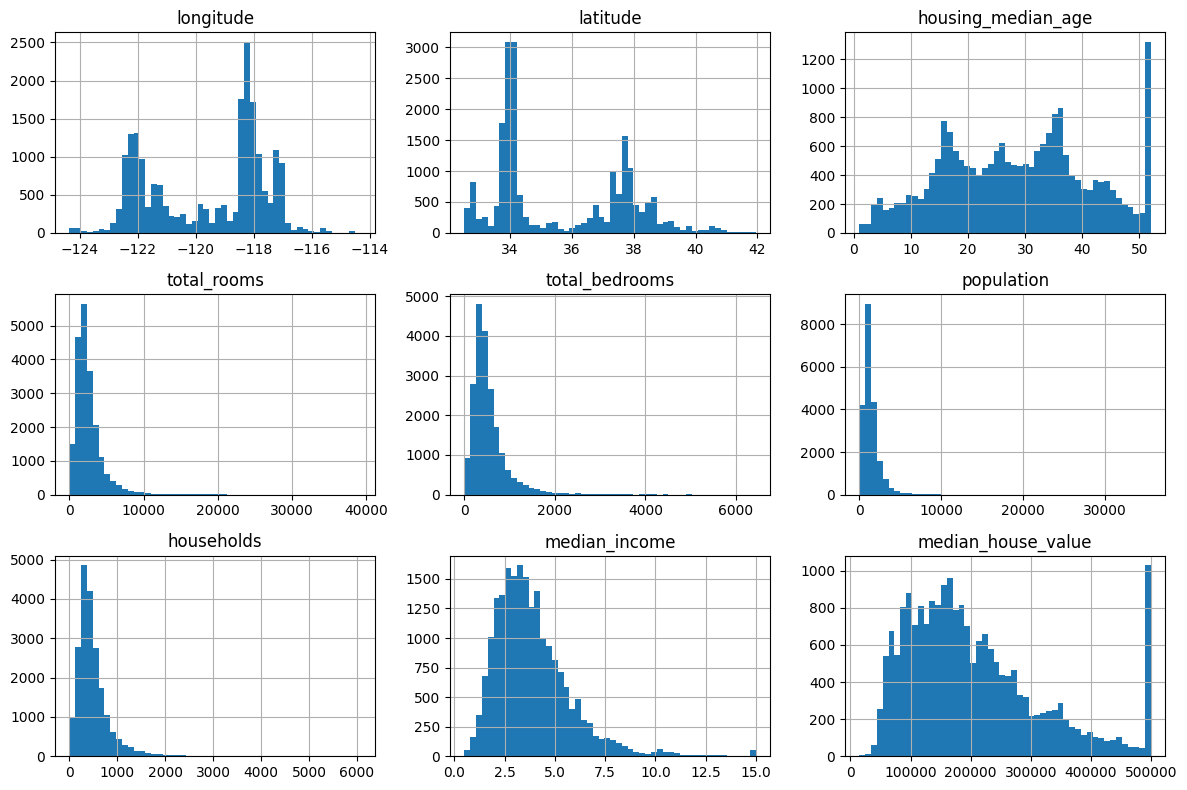

          longitude      latitude  housing_median_age   total_rooms  \
count  20640.000000  20640.000000        20640.000000  20640.000000   
mean    -119.569704     35.631861           28.639486   2635.763081   
std        2.003532      2.135952           12.585558   2181.615252   
min     -124.350000     32.540000            1.000000      2.000000   
25%     -121.800000     33.930000           18.000000   1447.750000   
50%     -118.490000     34.260000           29.000000   2127.000000   
75%     -118.010000     37.710000           37.000000   3148.000000   
max     -114.310000     41.950000           52.000000  39320.000000   

       total_bedrooms    population    households  median_income  \
count    20433.000000  20640.000000  20640.000000   20640.000000   
mean       537.870553   1425.476744    499.539680       3.870671   
std        421.385070   1132.462122    382.329753       1.899822   
min          1.000000      3.000000      1.000000       0.499900   
25%        296.00000

In [74]:
import matplotlib.pyplot as plt

# Quick visual check across all numeric columns
df.hist(bins=50, figsize=(12, 8))
plt.tight_layout()
plt.show()

# Quick summary check for exact max values
print(df.describe())

<Axes: >

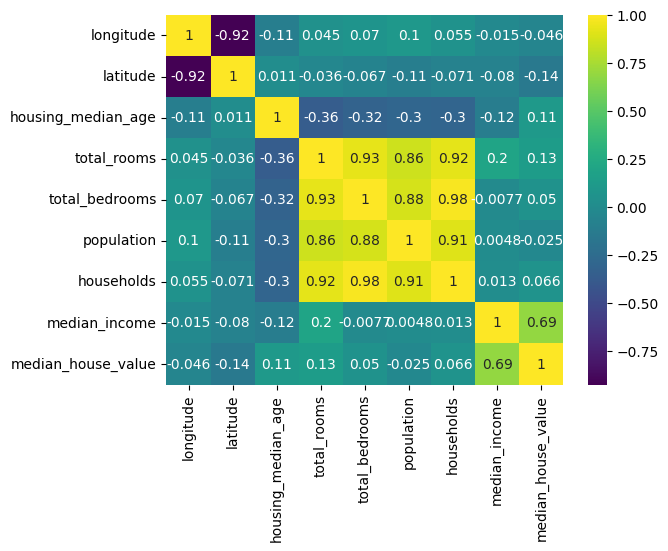

In [75]:
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="viridis")

The correlation matrix heatmap highlights key feature relationships, most notably a strong positive correlation between `median_income` and `median_house_value` (0.69), identifying income as the strongest single predictor of house values. High multicollinearity is evident among `total_rooms`, `total_bedrooms`, `population`, and `households` (correlations ranging from 0.86 to 0.98), indicating that these features convey redundant scale information and should be combined into ratio metrics (e.g., rooms per household). Additionally, `latitude` and `longitude` exhibit a strong negative correlation (-0.92) due to the northwest-to-southeast geographic orientation of California, while individual raw feature correlations with house values remain relatively weak apart from income.

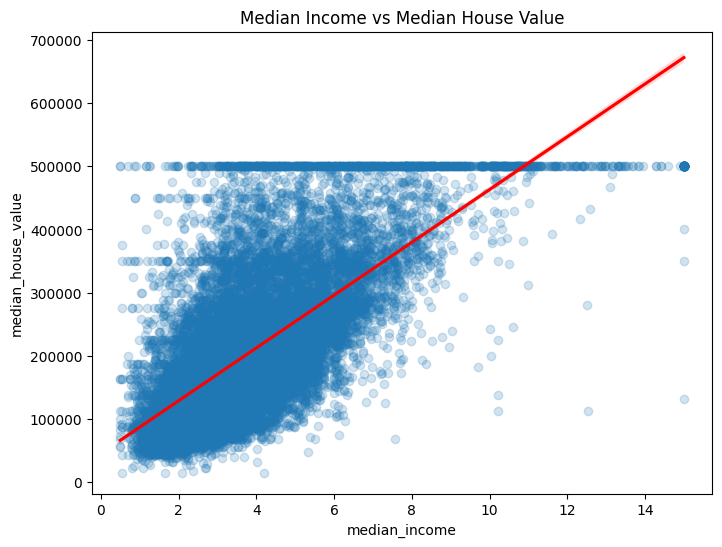

In [76]:
plt.figure(figsize=(8, 6))

sns.regplot(
    data=df,
    x='median_income',
    y='median_house_value',
    scatter_kws={'alpha': 0.2},
    line_kws={'color': 'red'}
)

plt.title("Median Income vs Median House Value")
plt.show()

The scatter plot demonstrates a strong positive linear relationship between `median_income` and `median_house_value`, as highlighted by the upward-sloping red regression line. However, the plot clearly reveals prominent horizontal price caps, most notably the solid ceiling at $500,000 where values were truncated during collection, alongside subtle secondary horizontal lines around $450,000, $350,000, and $280,000. These artificial boundary artifacts pull the fitted regression line away from the actual trend, emphasizing the need to drop or filter these capped data points during preprocessing to prevent models from learning distorted predictions.

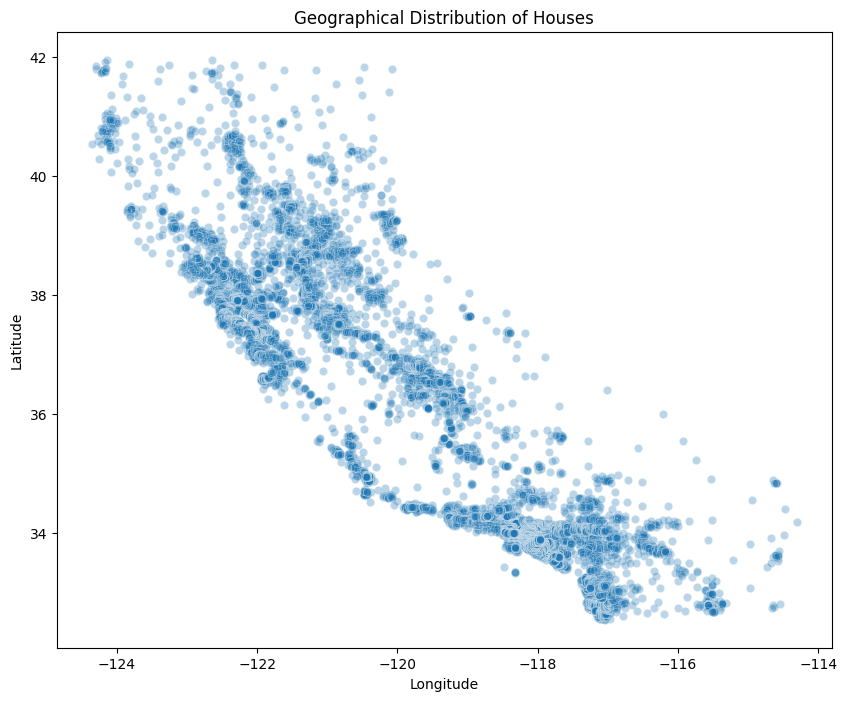

In [77]:
plt.figure(figsize=(10, 8))

sns.scatterplot(
    data=df,
    x='longitude',
    y='latitude',
    alpha=0.3
)

plt.title("Geographical Distribution of Houses")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

The scatter plot visualizes the spatial arrangement of housing districts across California using `Longitude` and `Latitude` coordinates, explicitly tracing out the state's geographic coastline and major metropolitan centers. High point density (darker blue clusters) reveals two major urban population hubs—the San Francisco Bay Area in the north (around latitude 37.5–38) and Greater Los Angeles/San Diego in the south (around latitude 32.5–34). The lower density of data points across the interior regions highlights sparse rural settlement patterns, underscoring the necessity of engineering spatial features—such as geographic clustering or distance metrics to coastal hubs—to capture these non-linear location effects during modeling.

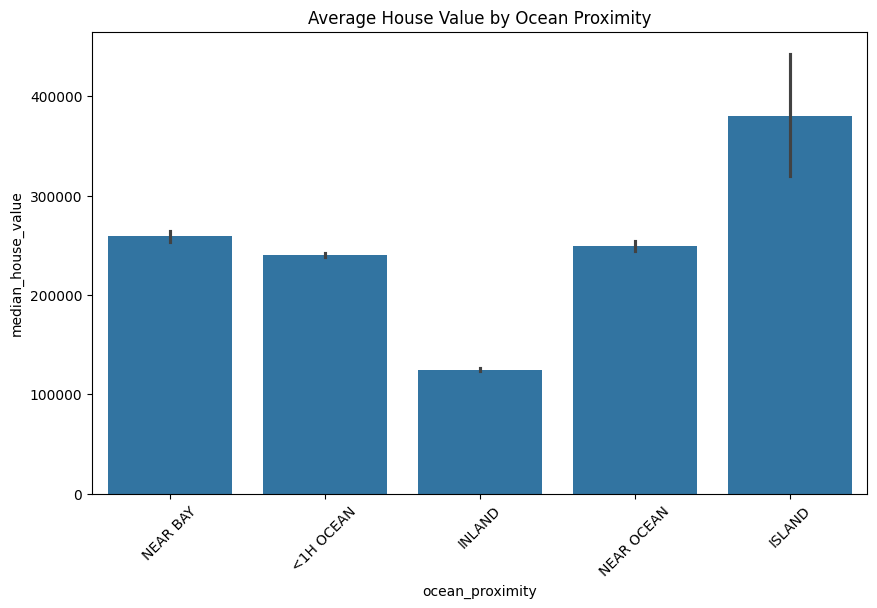

In [78]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df,
    x='ocean_proximity',
    y='median_house_value',
    estimator='mean'
)

plt.title("Average House Value by Ocean Proximity")
plt.xticks(rotation=45)
plt.show()



The bar plot illustrates the mean `median_house_value` across categorical levels of `ocean_proximity`, demonstrating a strong premium associated with coastal location. Properties categorized as **ISLAND** command the highest average house value (approaching $380,000), though its wide error bar indicates a small sample size and higher variance. Coastal categories—**NEAR BAY**, **<1H OCEAN**, and **NEAR OCEAN**—maintain tightly bounded, similar mean values hovering around $240,000–$260,000. Conversely, **INLAND** properties record the lowest mean value by a significant margin (around $125,000), confirming that geographic proximity to the ocean acts as a primary positive driver of property valuations.

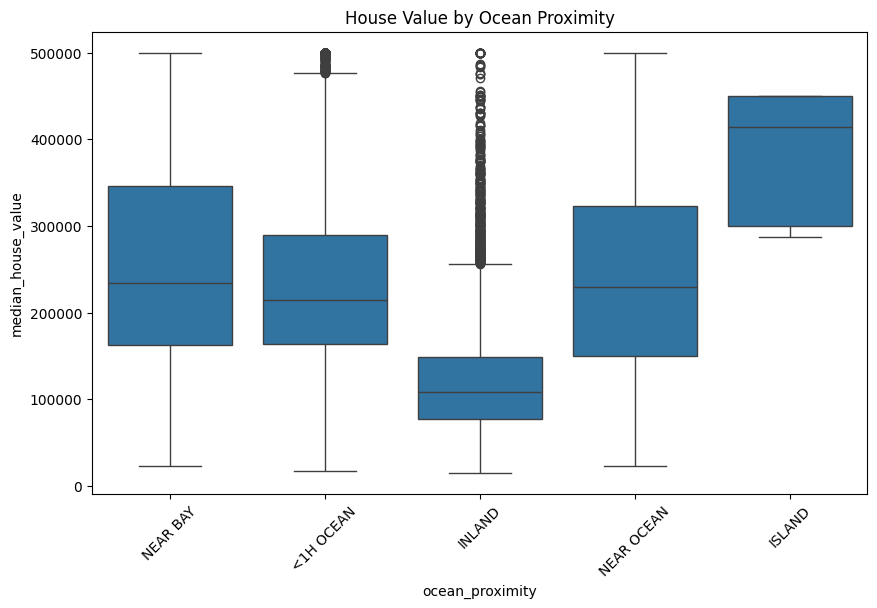

In [79]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='ocean_proximity',
    y='median_house_value'
)

plt.title("House Value by Ocean Proximity")
plt.xticks(rotation=45)
plt.show()

The boxplot distribution of `median_house_value` across `ocean_proximity` categories confirms significant valuation disparities driven by geography, with **ISLAND** properties commanding the highest median price (around $415,000) and **INLAND** homes recording the lowest overall median valuation (around $110,000). While coastal categories (**NEAR BAY**, **<1H OCEAN**, and **NEAR OCEAN**) exhibit broad interquartile ranges extending up to $300,000–$350,000, several regions—most prominently **<1H OCEAN** and **INLAND**—display a dense cluster of high-end outliers extending up to the artificial upper ceiling of $500,000. Furthermore, the horizontal top whiskers capped uniformly at $500,000 across multiple categories reinforce the global nature of the target variable capping artifact, emphasizing the importance of filtering out these boundary values prior to modeling.

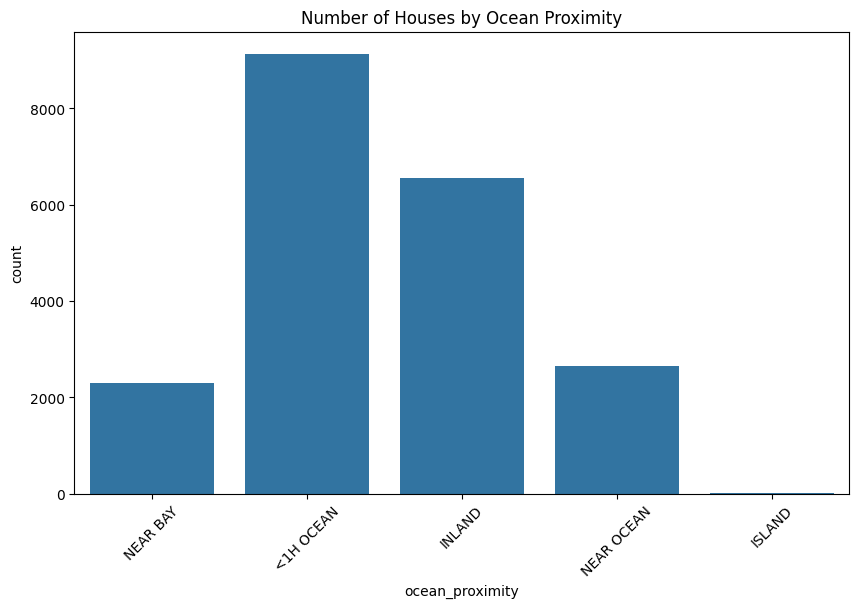

In [80]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x='ocean_proximity'
)

plt.title("Number of Houses by Ocean Proximity")
plt.xticks(rotation=45)
plt.show()

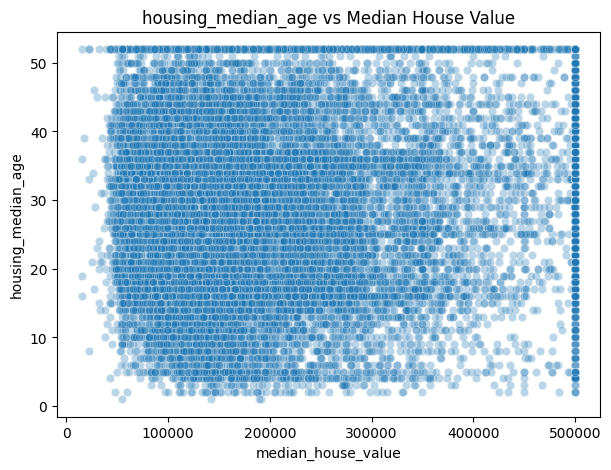

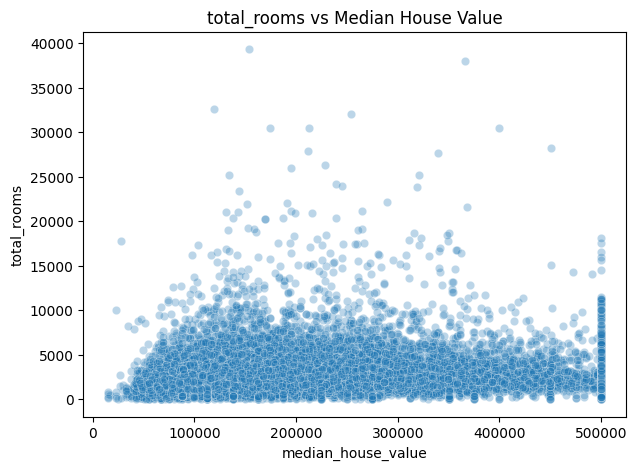

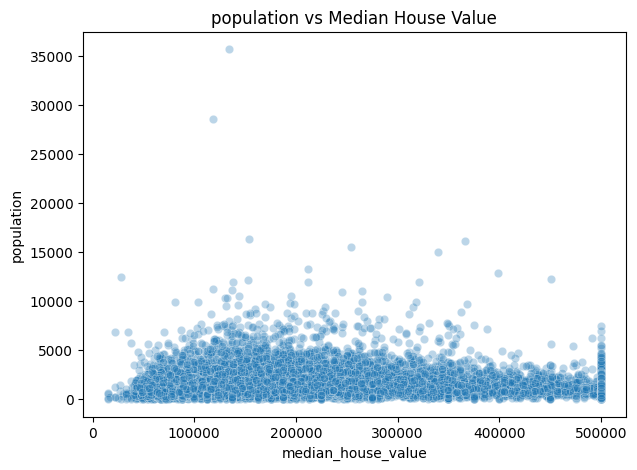

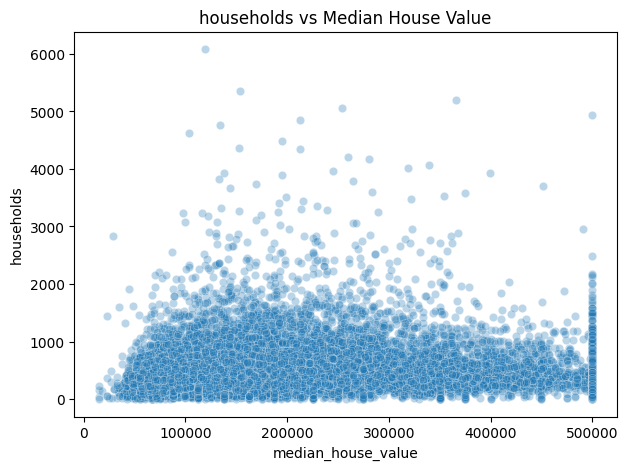

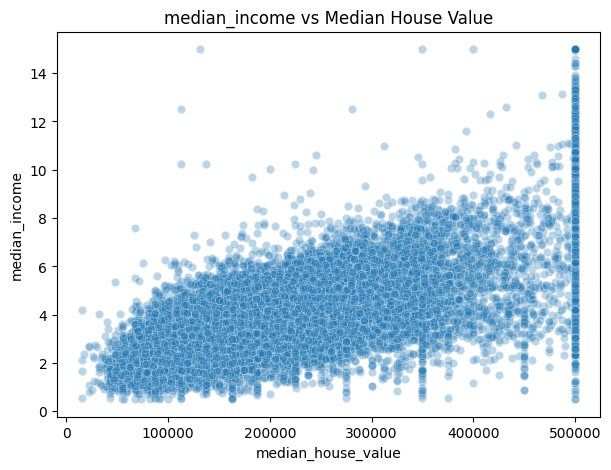

In [81]:
features = [
    'housing_median_age',
    'total_rooms',
    'population',
    'households',
    'median_income'
]

for feature in features:
    plt.figure(figsize=(7, 5))

    sns.scatterplot(
        data=df,
        y=feature,
        x='median_house_value',
        alpha=0.3
    )

    plt.title(f'{feature} vs Median House Value')
    plt.show()

Feature Engineering

In [82]:
df.isna().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [83]:
df.total_bedrooms=df.total_bedrooms.fillna(df.total_bedrooms.median())

In [84]:
df.isna().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [85]:
#Fixing median house value capped at 500000,500001
df = df[df["median_house_value"] < 500000].copy()

In [86]:
#Fixing age capped problems
bins = [0, 10, 20, 35, 50, np.inf]
labels = ["0-10", "11-20", "21-35", "36-50", "50+"]
df["age_category"] = pd.cut(
    df["housing_median_age"], bins=bins, labels=labels, right=True
)

In [87]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,age_category
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,36-50
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,21-35
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,50+
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,50+
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,50+
...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND,21-35
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND,11-20
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND,11-20
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND,11-20


In [88]:
df["rooms_per_household"] = df["total_rooms"] / df["households"]
df["bedrooms_per_room"] = df["total_bedrooms"] / df["total_rooms"]
df["population_per_household"] = df["population"] / df["households"]

In [89]:
#Handeling skewness
skewed_cols = [
    "total_rooms",
    "total_bedrooms",
    "population",
    "households",
    "rooms_per_household",
    "bedrooms_per_room",
    "population_per_household",
]

for col in skewed_cols:
    df[f"{col}_log"] = np.log1p(df[col])

In [90]:
from sklearn.cluster import KMeans
coords = df[["latitude", "longitude"]]
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
df["geo_cluster"] = kmeans.fit_predict(coords)

In [91]:
df.isna().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [92]:
df.drop(columns=skewed_cols,inplace=True)

In [93]:
df.drop(columns=coords,inplace=True)

In [98]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans

# Re-initialize df and apply necessary transformations up to this point
df = pd.read_csv("/content/housing.csv")

df.total_bedrooms = df.total_bedrooms.fillna(df.total_bedrooms.median())
df = df[df["median_house_value"] < 500000].copy()

bins = [0, 10, 20, 35, 50, np.inf]
labels = ["0-10", "11-20", "21-35", "36-50", "50+"]
df["age_category"] = pd.cut(df["housing_median_age"], bins=bins, labels=labels, right=True)

df["rooms_per_household"] = df["total_rooms"] / df["households"]
df["bedrooms_per_room"] = df["total_bedrooms"] / df["total_rooms"]
df["population_per_household"] = df["population"] / df["households"]

skewed_cols_names = [
    "total_rooms",
    "total_bedrooms",
    "population",
    "households",
    "rooms_per_household",
    "bedrooms_per_room",
    "population_per_household",
]
for col in skewed_cols_names:
    df[f"{col}_log"] = np.log1p(df[col])

coords_columns = ["latitude", "longitude"]
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
df["geo_cluster"] = kmeans.fit_predict(df[coords_columns])

# Drop original skewed columns and coordinates
df.drop(columns=skewed_cols_names, inplace=True)
df.drop(columns=coords_columns, inplace=True)

# Now perform the one-hot encoding as originally intended by the corrected code
df_dummies = pd.get_dummies(df[["ocean_proximity", "age_category"]], drop_first=True).astype(int)
df = df.drop(columns=["ocean_proximity", "age_category"])
df = pd.concat([df, df_dummies], axis=1)

In [99]:
X=df.drop("median_house_value",axis=1)
y=df["median_house_value"]

In [100]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [101]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [104]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train_scaled,y_train)
y_pred=model.predict(X_test_scaled)

In [105]:
from sklearn.metrics import mean_squared_error,r2_score
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)

In [106]:
print(mse)
print(r2)

3539872209.6708426
0.6259383017107367
